# 05 - Multivariate Analysis

Combining multiple variables simultaneously through pair plots, grouped aggregations, and pivot tables to uncover deeper, segment-level patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../dataset/cleaned_ecommerce_data.csv')
df.head()

,order_id,age,gender,category,payment_method,total_spend,delivery_days,rating,is_returned,order_date,age_group,satisfaction_level,order_month
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,0,2022-01-01,36-45,Medium,2022-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,1,2022-01-02,36-45,Low,2022-01
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,0,2022-01-03,26-35,Medium,2022-01
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,0,2022-01-04,56+,High,2022-01
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,0,2022-01-05,56+,Medium,2022-01


## Pair Plot of Key Numerical Features

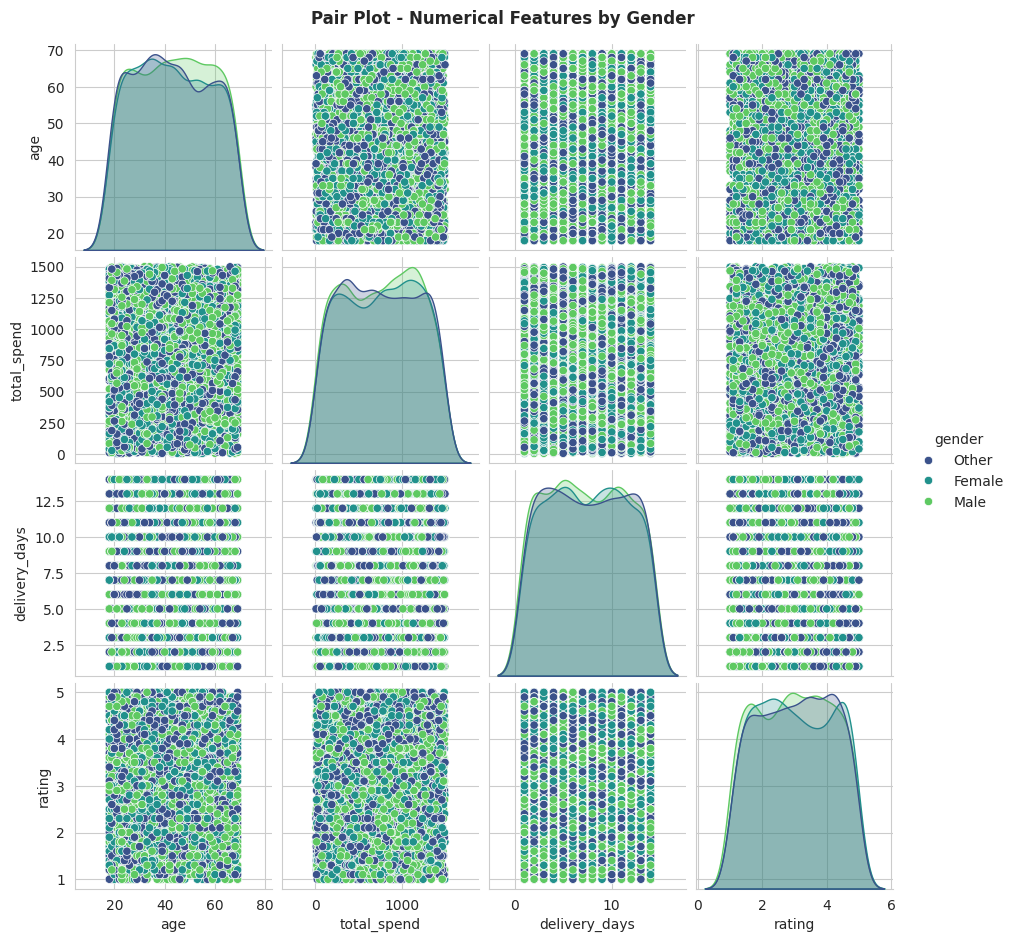

In [2]:
num_cols = ['age', 'total_spend', 'delivery_days', 'rating']
g = sns.pairplot(df[num_cols + ['gender']], hue='gender', palette='viridis', diag_kind='kde', height=2.3)
g.fig.suptitle('Pair Plot - Numerical Features by Gender', y=1.02, fontweight='bold')
g.savefig('../screenshots/05_pairplot.png', dpi=100)
plt.show()

**Observation:** The pair plot confirms that gender groups overlap heavily across all numerical dimensions, reinforcing that demographic alone doesn't strongly separate purchasing behavior — category and payment choices matter more.

## Full Correlation Matrix & Heatmap

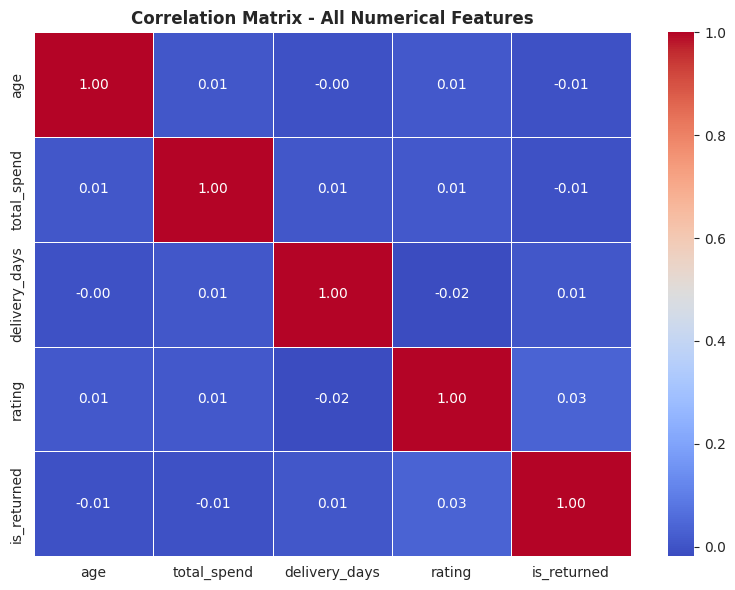

,age,total_spend,delivery_days,rating,is_returned
age,1.000000,0.006178,-0.004570,0.012011,-0.005416
total_spend,0.006178,1.000000,0.005555,0.012273,-0.005603
delivery_days,-0.004570,0.005555,1.000000,-0.018721,0.008995
rating,0.012011,0.012273,-0.018721,1.000000,0.033337
is_returned,-0.005416,-0.005603,0.008995,0.033337,1.000000


In [3]:
num_cols_full = ['age', 'total_spend', 'delivery_days', 'rating', 'is_returned']
corr_matrix = df[num_cols_full].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - All Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_correlation_matrix.png', dpi=100)
plt.show()
corr_matrix

## GroupBy: Gender x Category -> Average Spend

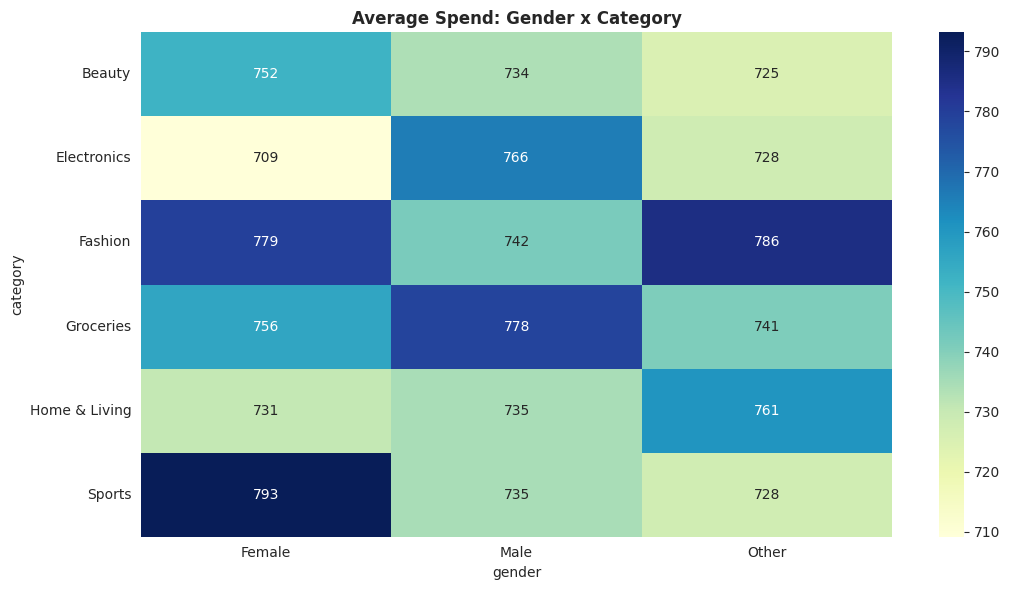

gender,Female,Male,Other
category,,,
Beauty,751.939255,733.958562,725.274839
Electronics,709.207857,765.629967,728.158456
Fashion,779.439858,741.541758,785.591892
Groceries,755.895233,778.495358,741.016151
Home & Living,730.768566,734.741200,760.500985
Sports,793.174899,734.508582,727.729857


In [4]:
grouped = df.groupby(['gender', 'category'], observed=True)['total_spend'].mean().reset_index()
pivot1 = grouped.pivot(index='category', columns='gender', values='total_spend')
plt.figure(figsize=(11,6))
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Spend: Gender x Category', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_gender_category_spend.png', dpi=100)
plt.show()
pivot1

## Pivot Table: Payment Method x Satisfaction Level -> Order Count

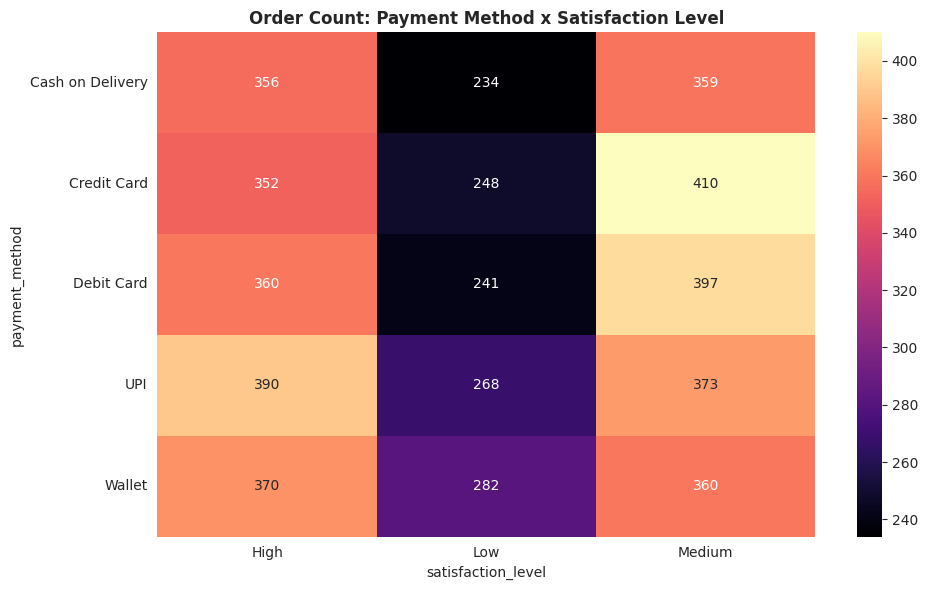

satisfaction_level,High,Low,Medium
payment_method,,,
Cash on Delivery,356,234,359
Credit Card,352,248,410
Debit Card,360,241,397
UPI,390,268,373
Wallet,370,282,360


In [5]:
pivot2 = pd.pivot_table(df, index='payment_method', columns='satisfaction_level',
                          values='order_id', aggfunc='count', observed=True)
plt.figure(figsize=(10,6))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='magma')
plt.title('Order Count: Payment Method x Satisfaction Level', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_payment_satisfaction_pivot.png', dpi=100)
plt.show()
pivot2

## Multi-variable Comparison: Category x Age Group -> Avg Rating & Spend

In [6]:
multi = df.groupby(['category', 'age_group'], observed=True).agg(
    avg_spend=('total_spend', 'mean'),
    avg_rating=('rating', 'mean'),
    order_count=('order_id', 'count')
).reset_index()
multi.sort_values(['category', 'age_group']).head(15)

,category,age_group,avg_spend,avg_rating,order_count
0,Beauty,18-25,732.564806,2.987597,129
1,Beauty,26-35,716.553585,2.946541,159
2,Beauty,36-45,764.626185,3.053179,173
3,Beauty,46-55,752.334643,2.954762,168
4,Beauty,56+,721.468839,3.102679,224
5,Electronics,18-25,752.954341,2.987597,129
6,Electronics,26-35,755.849032,3.014839,155
7,Electronics,36-45,698.073000,2.957333,150
8,Electronics,46-55,708.685556,3.088148,135
9,Electronics,56+,757.478377,3.015351,228


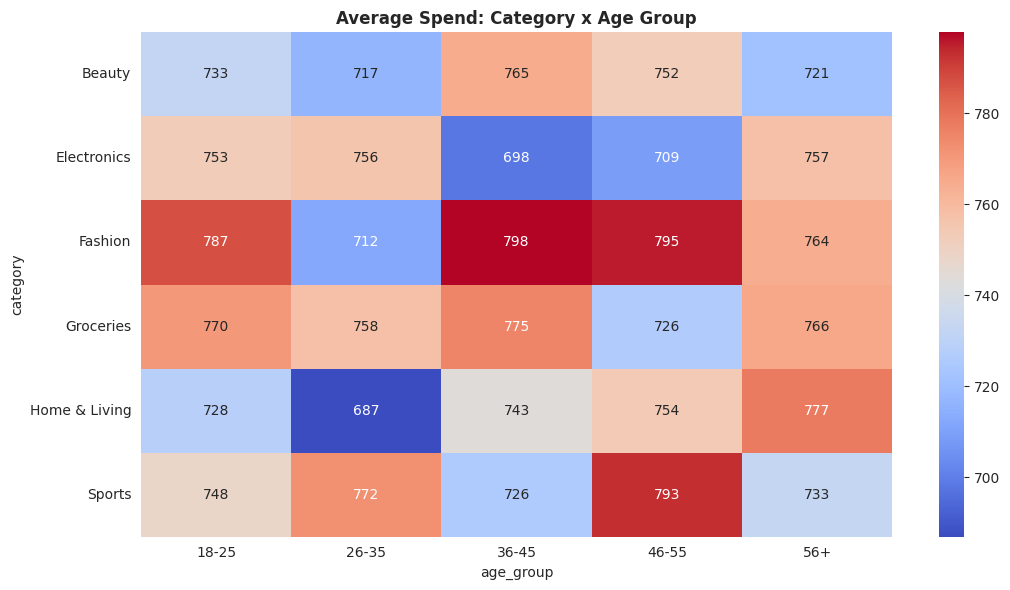

In [7]:
pivot3 = multi.pivot(index='category', columns='age_group', values='avg_spend')
plt.figure(figsize=(11,6))
sns.heatmap(pivot3, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Average Spend: Category x Age Group', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_category_agegroup_spend.png', dpi=100)
plt.show()

## Returns Rate by Category and Payment Method

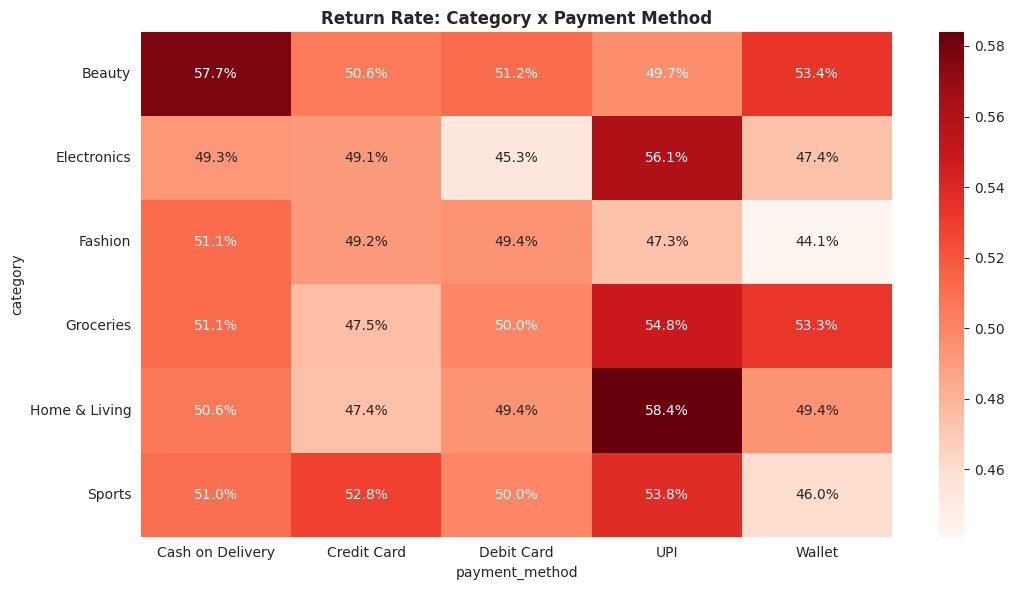

In [8]:
return_rate = df.groupby(['category', 'payment_method'], observed=True)['is_returned'].mean().reset_index()
pivot4 = return_rate.pivot(index='category', columns='payment_method', values='is_returned')
plt.figure(figsize=(11,6))
sns.heatmap(pivot4, annot=True, fmt='.1%', cmap='Reds')
plt.title('Return Rate: Category x Payment Method', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_return_rate_heatmap.png', dpi=100)
plt.show()

## Multivariate Analysis Summary

- The **pair plot** confirms numerical features (age, spend, delivery time, rating) don't form tight clusters by gender alone.
- The **gender x category spend heatmap** pinpoints which category-gender combinations generate the highest average order value — a direct input for targeted marketing.
- The **payment x satisfaction pivot** reveals whether certain payment methods correlate with happier or less happy customers.
- The **category x age-group spend heatmap** identifies the highest-value age segment per category, supporting personalized promotions.
- The **return-rate heatmap** flags specific category/payment combinations with elevated return risk, useful for fraud/quality investigation.
- These combined views set up the actionable conclusions delivered in **Notebook 06 - Business Insights**.